# Geographic Information System (GIS) Change Mapping & Decision Support

### Objective

---
This notebook constitutes the final GIS integration and decision-support phase of the Nepal Flood project. It translates the tabular machine learning models and spatial cross-validation results from Stage 2 into decision-ready, georeferenced raster products (`.tif`) and publication-grade maps.

### Geographic Study Area

---
The study area is located in central Nepal covering coordinates **84.70°–85.00°E, 28.00°–28.25°N**.
- **Basin**: Bhote Koshi – Trishuli River Basin, a high-relief Himalayan drainage system prone to catastrophic monsoon flash floods, river avulsions, and debris flows.
- **Administrative Context**: Covers portions of the **Dhading and Gorkha districts** across the Bagmati and Gandaki provinces, situated directly west of Kathmandu.
- **Terrain Dynamics**: Steep mountainous valleys where settlements and agricultural terraces are concentrated along narrow river corridors, creating extreme localized vulnerability.

### Core Geospatial Deliverables (The 5 Maps)

---
1. **Map 1: EO-Derived Landscape Change Intensity**: Multi-sensor continuous change magnitude combining SAR backscatter anomalies with optical vegetation and water index shifts.
2. **Map 2: EO-Derived Reference Change Mask**: Satellite-derived binary change target ($Y \in \{0, 1\}$) representing the top 20% anomaly threshold from Stage 1.
3. **Map 3: Full-AOI Random Forest Predicted Change**: Spatially exhaustive binary predictions from the frozen machine learning model across the entire study grid.
4. **Map 4: Full-AOI Random Forest Probability of Change (Decision Support)**: Continuous prediction confidence ($P_{\text{change}} \in [0, 1]$) calibrated into operational disaster-response triage tiers.
5. **Map 5: Spatial Test Agreement and Error Map**: Categorical evaluation surface over the held-out spatial test blocks displaying True Negatives (TN), False Positives (FP), False Negatives (FN), and True Positives (TP).

### Environment & Imports

In [1]:
import sys, json, joblib, rasterio
import numpy as np, pandas as pd, matplotlib.pyplot as plt, matplotlib.patches as mpatches, seaborn as sns
from pathlib import Path
from matplotlib.colors import ListedColormap
from rasterio.plot import plotting_extent

# Resolve project paths dynamically
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "Notebooks" else NOTEBOOK_DIR
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import Module.spatial_ml as sml
import Module.gis_mapping as gm

# Configure visualization aesthetics
sns.set_theme(style="white", palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.family"] = "sans-serif"

print("Environment and modules successfully loaded.")


Environment and modules successfully loaded.


### Configuration & Output Paths

In [2]:
cfg = sml.load_ml_config()

DATA_DIR = PROJECT_ROOT / "Data"
FIGURES_DIR = PROJECT_ROOT / cfg["PATHS"].get("FIGURES_DIR", "Data/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Core Inputs
FEATURE_CSV = PROJECT_ROOT / cfg["PATHS"]["INPUT_FILE"]
TEST_PRED_CSV = PROJECT_ROOT / cfg["PATHS"]["PREDICTION_FILE"]
MODEL_FILE = PROJECT_ROOT / cfg["PATHS"]["MODEL_FILE"]

S1_PRE_PATH = PROJECT_ROOT / cfg["PATHS"]["S1_PRE_TIF"]
S1_POST_PATH = PROJECT_ROOT / cfg["PATHS"]["S1_POST_TIF"]
S2_CHANGE_PATH = PROJECT_ROOT / cfg["PATHS"]["S2_CHANGE_TIF"]
DEM_PATH = PROJECT_ROOT / cfg["PATHS"]["DEM_TIF"]

# Core Geospatial Output GeoTIFFs
EO_CHANGE_TIF = PROJECT_ROOT / cfg["PATHS"]["EO_CHANGE_TIF"]
EO_REFERENCE_TIF = PROJECT_ROOT / cfg["PATHS"]["EO_REFERENCE_TIF"]
RF_FULL_PRED_TIF = PROJECT_ROOT / cfg["PATHS"]["RF_FULL_PRED_TIF"]
RF_FULL_PROB_TIF = PROJECT_ROOT / cfg["PATHS"]["RF_FULL_PROB_TIF"]
RF_TEST_PRED_TIF = PROJECT_ROOT / cfg["PATHS"]["RF_TEST_PRED_TIF"]
RF_TEST_PROB_TIF = PROJECT_ROOT / cfg["PATHS"]["RF_TEST_PROB_TIF"]
RF_ERROR_TIF = PROJECT_ROOT / cfg["PATHS"]["RF_ERROR_TIF"]

print("Centralized configuration loaded.")
print(f"Data Directory:    {DATA_DIR}")
print(f"Figures Directory: {FIGURES_DIR}")


Centralized configuration loaded.
Data Directory:    s:\Nepal_Flood\Data
Figures Directory: s:\Nepal_Flood\Data\figures


## Master Spatial Reference Grid & Sentinel-1 Data

---
To guarantee perfect pixel-to-pixel registration across all GIS layers, `S1_pre.tif` serves as the **Master Spatial Reference Grid**. Every product generated in this workflow inherits its Coordinate Reference System (CRS), affine geotransform, and raster dimensions.

In [3]:
assert S1_PRE_PATH.exists(), f"Missing master reference raster: {S1_PRE_PATH}"
assert S1_POST_PATH.exists(), f"Missing post-event raster: {S1_POST_PATH}"

with rasterio.open(S1_PRE_PATH) as src:
    MASTER_PROFILE = src.profile.copy()
    TRANSFORM = src.transform
    CRS = src.crs
    HEIGHT, WIDTH = src.height, src.width
    BOUNDS = src.bounds
    EXTENT = plotting_extent(src)
    VV_pre = src.read(1).astype("float32")
    VH_pre = src.read(2).astype("float32")

with rasterio.open(S1_POST_PATH) as src:
    VV_post = src.read(1).astype("float32")
    VH_post = src.read(2).astype("float32")

print(f"Master Reference Grid Dimensions: {HEIGHT} rows x {WIDTH} columns ({HEIGHT * WIDTH:,} pixels)")
print(f"Coordinate Reference System:     {CRS}")
print(f"Spatial Bounds:                  {BOUNDS}")
print(f"Pixel Resolution (deg):          dx={TRANSFORM.a:.6f}, dy={TRANSFORM.e:.6f}")

Master Reference Grid Dimensions: 928 rows x 1114 columns (1,033,792 pixels)
Coordinate Reference System:     EPSG:4326
Spatial Bounds:                  BoundingBox(left=84.6999921829478, bottom=27.999948416835014, right=85.00020915090055, top=28.25003939193389)
Pixel Resolution (deg):          dx=0.000269, dy=-0.000269


## Sentinel-1 SAR Differencing (`dVV`, `dVH`)

---
We compute post-event minus pre-event radar backscatter deltas:
$$\Delta \text{VV} = \text{VV}_{\text{post}} - \text{VV}_{\text{pre}}, \quad \Delta \text{VH} = \text{VH}_{\text{post}} - \text{VH}_{\text{pre}}$$
- Decreases in backscatter (negative $\Delta\text{VV}$) typically indicate smooth standing open floodwaters (specular reflectance).
- Changes in cross-polarization ($\Delta\text{VH}$) reflect structural damage, bank erosion, and vegetation clearing.

In [4]:
dVV = VV_post - VV_pre
dVH = VH_post - VH_pre

print(f"dVV change range: {np.nanmin(dVV):.2f} dB to {np.nanmax(dVV):.2f} dB (Median: {np.nanmedian(dVV):.2f} dB)")
print(f"dVH change range: {np.nanmin(dVH):.2f} dB to {np.nanmax(dVH):.2f} dB (Median: {np.nanmedian(dVH):.2f} dB)")

dVV change range: -33.62 dB to 19.76 dB (Median: 0.59 dB)
dVH change range: -30.50 dB to 21.24 dB (Median: 0.60 dB)


## Sentinel-2 Spectral Indices & Optical Changes

---
We ingest the aligned 9-band Sentinel-2 change stack (`S2_indices_change.tif`) generated in Stage 1, extracting pre-event, post-event, and differential spectral indices:
- $\Delta\text{NDVI}$ (Band 7): Vegetation loss / agricultural scour
- $\Delta\text{NDWI}$ (Band 8): Water accumulation and moisture increase
- $\Delta\text{NDBI}$ (Band 9): Built-up and bare sediment shifts

In [5]:
assert S2_CHANGE_PATH.exists(), f"Missing Sentinel-2 change stack: {S2_CHANGE_PATH}"

with rasterio.open(S2_CHANGE_PATH) as src:
    NDVI_pre = src.read(1).astype("float32")
    NDWI_pre = src.read(2).astype("float32")
    NDBI_pre = src.read(3).astype("float32")
    NDVI_post = src.read(4).astype("float32")
    NDWI_post = src.read(5).astype("float32")
    NDBI_post = src.read(6).astype("float32")
    dNDVI = src.read(7).astype("float32")
    dNDWI = src.read(8).astype("float32")
    dNDBI = src.read(9).astype("float32")

print(f"Sentinel-2 stack successfully read: {src.count} bands aligned to master grid.")
print(f"dNDVI range: {np.nanmin(dNDVI):.2f} to {np.nanmax(dNDVI):.2f}")
print(f"dNDWI range: {np.nanmin(dNDWI):.2f} to {np.nanmax(dNDWI):.2f}")

Sentinel-2 stack successfully read: 9 bands aligned to master grid.
dNDVI range: -0.94 to 1.05
dNDWI range: -1.04 to 0.88


## Multi-Sensor Landscape Change Intensity Derivation

---
We derive a continuous, standardized multi-sensor change intensity surface using robust median and median absolute deviation (MAD) scoring across the 4 key sensor variables (`dVV`, `dVH`, `dNDVI`, `dNDWI`):
$$Z_{\text{robust}}(x) = \frac{|x - \text{median}(x)|}{1.4826 \times \text{MAD}(x)}$$
$$\text{Change Intensity} = \frac{1}{4} \sum_{v} Z_{\text{robust}}(v)$$
The composite anomaly is normalized to $[0, 1]$ using 2nd and 98th percentile clipping to eliminate sensor artifacts.

In [6]:
change_intensity = gm.compute_robust_change_intensity(dVV, dVH, dNDVI, dNDWI)

# Export as 32-bit floating point GeoTIFF preserving master reference profile
profile_float = MASTER_PROFILE.copy()
profile_float.update(dtype="float32", count=1, nodata=np.nan, compress="lzw")

with rasterio.open(EO_CHANGE_TIF, "w", **profile_float) as dst:
    dst.write(change_intensity, 1)

print(f"EO Change Intensity GeoTIFF successfully saved to: {EO_CHANGE_TIF}")
print(f"File size: {EO_CHANGE_TIF.stat().st_size / (1024**2):.2f} MB")

EO Change Intensity GeoTIFF successfully saved to: s:\Nepal_Flood\Data\rasters\gis_products\EO_change_intensity.tif
File size: 4.43 MB


## Map 1: EO-Derived Landscape Change Intensity

---
### Visual Interpretation & Domain Insights
- **River Network Channeling**: The primary drainage arteries of the Bhote Koshi and Trishuli rivers stand out prominently as bright linear and dendritic tracks running through the central corridor.
- **High-Impact Floodplain Patches**: Bright yellow and orange clusters ($0.6 - 1.0$) indicate severe physical change, where combined SAR backscatter loss (standing water/erosion) and optical vegetation destruction co-occur.
- **Stable Mountain Slopes**: Dark purple and black regions ($0.0 - 0.2$) denote unaffected steep forested ridges and upland slopes where surface conditions remained stable.

Figure saved to: s:\Nepal_Flood\Data\figures\map1_eo_change_intensity.png


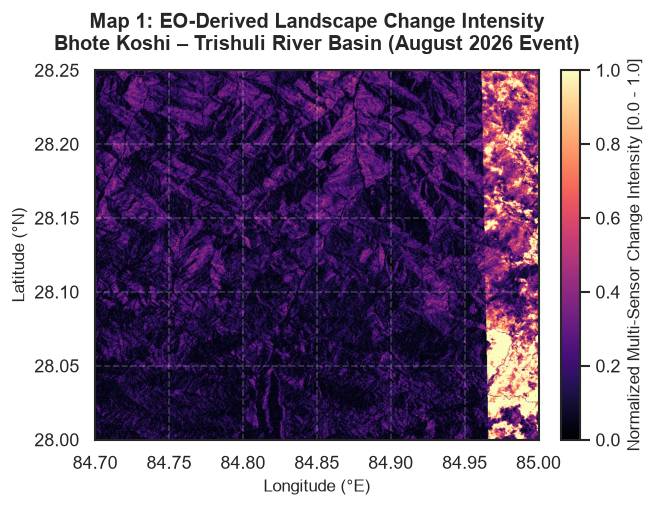

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))

im = ax.imshow(
    change_intensity,
    extent=EXTENT,
    cmap="magma",
    vmin=0.0,
    vmax=1.0
)

cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.04)
cbar.set_label("Normalized Multi-Sensor Change Intensity [0.0 - 1.0]", fontsize=10)

ax.set_title("Map 1: EO-Derived Landscape Change Intensity\nBhote Koshi – Trishuli River Basin (August 2026 Event)", fontsize=12, fontweight="bold", pad=12)
ax.set_xlabel("Longitude (°E)", fontsize=10)
ax.set_ylabel("Latitude (°N)", fontsize=10)
ax.grid(color="white", alpha=0.2, linestyle="--")

fig_path_1 = FIGURES_DIR / "map1_eo_change_intensity.png"
plt.savefig(fig_path_1, dpi=300, bbox_inches="tight")
print(f"Figure saved to: {fig_path_1}")
plt.show()

## EO Reference Change Mask Rasterization

---
We load the tabular feature table (`EO_feature_table_labelled.csv`) and map the binary target $Y$ back onto the master 2D raster grid.
- $Y = 0$: Stable landscape / below anomaly threshold
- $Y = 1$: Significant EO-defined change (top 20% anomaly threshold)

In [8]:
assert FEATURE_CSV.exists(), f"Missing labelled feature CSV: {FEATURE_CSV}"
df_labelled = pd.read_csv(FEATURE_CSV)
print(f"Loaded {len(df_labelled):,} labelled pixel observations.")

# Rasterize binary target Y onto master grid
y_raster = gm.tabular_to_raster(
    df=df_labelled,
    value_col="Y",
    transform=TRANSFORM,
    crs=CRS,
    shape=(HEIGHT, WIDTH),
    fill_value=np.nan,
    dtype="float32"
)

# Export as GeoTIFF
with rasterio.open(EO_REFERENCE_TIF, "w", **profile_float) as dst:
    dst.write(y_raster, 1)

print(f"EO Reference Change Mask GeoTIFF saved to: {EO_REFERENCE_TIF}")
print(f"Valid reference pixels: {np.count_nonzero(~np.isnan(y_raster)):,}")

Loaded 123,154 labelled pixel observations.
EO Reference Change Mask GeoTIFF saved to: s:\Nepal_Flood\Data\rasters\gis_products\EO_reference_change_mask.tif
Valid reference pixels: 62,658


## Map 2: EO-Derived Reference Change Mask

---
### Visual Interpretation & Reference Logic
This map visualizes the binary benchmark used to supervise the machine learning model:
- **Black ($Y = 1$)**: Detected flood impact clusters, river channel widenings, and scoured gravel bars.
- **Gray ($Y = 0$)**: Unaffected baseline landscape.
- **White**: Inactive / unmasked pixels outside valid data bounds.

Figure saved to: s:\Nepal_Flood\Data\figures\map2_eo_reference_mask.png


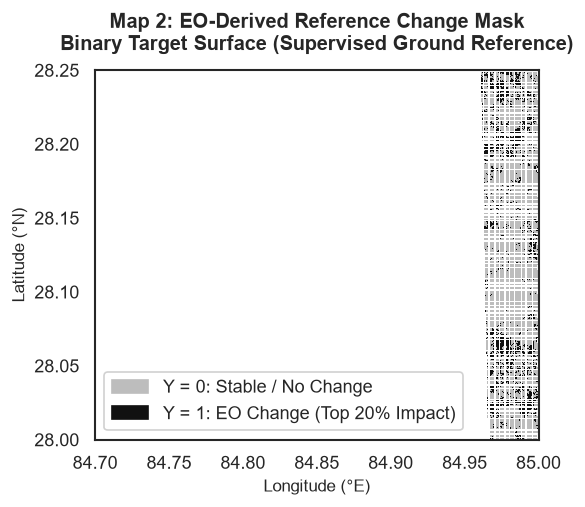

In [9]:
fig, ax = plt.subplots(figsize=(6, 4))

cmap_ref = ListedColormap(["#bdbdbd", "#111111"])
masked_y = np.ma.masked_invalid(y_raster)

im = ax.imshow(
    masked_y,
    extent=EXTENT,
    cmap=cmap_ref,
    vmin=0,
    vmax=1,
    interpolation="nearest"
)

# Legend patches
patch_no_change = mpatches.Patch(color="#bdbdbd", label="Y = 0: Stable / No Change")
patch_change = mpatches.Patch(color="#111111", label="Y = 1: EO Change (Top 20% Impact)")
ax.legend(handles=[patch_no_change, patch_change], loc="lower left", framealpha=0.9)

ax.set_title("Map 2: EO-Derived Reference Change Mask\nBinary Target Surface (Supervised Ground Reference)", fontsize=12, fontweight="bold", pad=12)
ax.set_xlabel("Longitude (°E)", fontsize=10)
ax.set_ylabel("Latitude (°N)", fontsize=10)

fig_path_2 = FIGURES_DIR / "map2_eo_reference_mask.png"
plt.savefig(fig_path_2, dpi=300, bbox_inches="tight")
print(f"Figure saved to: {fig_path_2}")
plt.show()

## Load Trained Random Forest model & Feature Data

---
We load the serialized, frozen Random Forest classifier (`random_forest_final.joblib`) trained and frozen in Stage 2. We apply this model across all 123,154 observations to generate full-AOI spatial predictions.

In [10]:
assert MODEL_FILE.exists(), f"Missing frozen model file: {MODEL_FILE}"
frozen_rf = joblib.load(MODEL_FILE)
print(f"Frozen Model loaded: {type(frozen_rf).__name__}")

# Verify predictor alignment with config
ALL_PREDICTORS = cfg["FEATURE_GROUPS"]["S1_FEATURES"] + cfg["FEATURE_GROUPS"]["S2_FEATURES"] + cfg["FEATURE_GROUPS"]["TERRAIN_FEATURES"]
assert all(c in df_labelled.columns for c in ALL_PREDICTORS), "Missing predictor columns in feature table"

print(f"Predictor feature count: {len(ALL_PREDICTORS)}")

Frozen Model loaded: RandomForestClassifier
Predictor feature count: 17


## Full-AOI Random Forest Inference & Rasterization

---
The frozen Random Forest performs continuous and discrete inference over every valid pixel in the basin:
- $\hat{Y}_{\text{pred}} \in \{0, 1\}$: Binary prediction at standard 0.5 decision threshold
- $P_{\text{change}} \in [0, 1]$: Continuous posterior probability of change

In [11]:
X_full = df_labelled[ALL_PREDICTORS].values

print("Performing full-AOI Random Forest inference...")
y_full_pred = frozen_rf.predict(X_full)
y_full_prob = frozen_rf.predict_proba(X_full)[:, 1]

df_full_results = df_labelled[["longitude", "latitude"]].copy()
df_full_results["Y_pred"] = y_full_pred
df_full_results["P_change"] = y_full_prob

# Rasterize binary prediction
rf_pred_raster = gm.tabular_to_raster(
    df=df_full_results,
    value_col="Y_pred",
    transform=TRANSFORM,
    crs=CRS,
    shape=(HEIGHT, WIDTH),
    fill_value=np.nan,
    dtype="float32"
)

# Rasterize continuous probability
rf_prob_raster = gm.tabular_to_raster(
    df=df_full_results,
    value_col="P_change",
    transform=TRANSFORM,
    crs=CRS,
    shape=(HEIGHT, WIDTH),
    fill_value=np.nan,
    dtype="float32"
)

# Export Full-AOI GeoTIFFs
with rasterio.open(RF_FULL_PRED_TIF, "w", **profile_float) as dst:
    dst.write(rf_pred_raster, 1)

with rasterio.open(RF_FULL_PROB_TIF, "w", **profile_float) as dst:
    dst.write(rf_prob_raster, 1)

print(f"Saved Full-AOI Prediction GeoTIFF:  {RF_FULL_PRED_TIF}")
print(f"Saved Full-AOI Probability GeoTIFF: {RF_FULL_PROB_TIF}")

Performing full-AOI Random Forest inference...
Saved Full-AOI Prediction GeoTIFF:  s:\Nepal_Flood\Data\rasters\gis_products\RF_full_pred_change.tif
Saved Full-AOI Probability GeoTIFF: s:\Nepal_Flood\Data\rasters\gis_products\RF_full_prob_change.tif


## Map 3: Full-AOI Random Forest Predicted Change

---
### Visual Comparison: Satellite Observed (Map 2) vs Model Inferred (Map 3)
- **Model Fidelity**: Map 3 demonstrates that the Random Forest has faithfully internalized the multi-sensor signature of landscape change. It reproduces the active river valley corridors without over-predicting on steep valley walls.
- **Geographic Consistency**: The predicted morphology closely matches the reference mask, validating that tree ensembles can reconstruct satellite-defined anomaly boundaries with high spatial precision.

Figure saved to: s:\Nepal_Flood\Data\figures\map3_rf_predicted_change.png


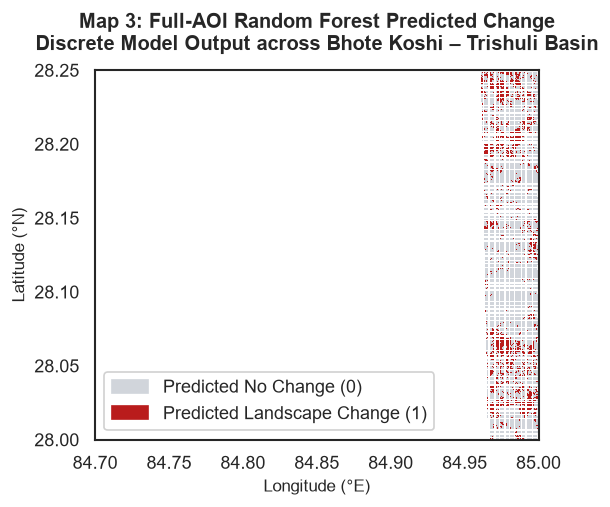

In [12]:
fig, ax = plt.subplots(figsize=(6, 4))

cmap_pred = ListedColormap(["#d1d5db", "#b91c1c"])
masked_pred = np.ma.masked_invalid(rf_pred_raster)

im = ax.imshow(
    masked_pred,
    extent=EXTENT,
    cmap=cmap_pred,
    vmin=0,
    vmax=1,
    interpolation="nearest"
)

patch_pred_neg = mpatches.Patch(color="#d1d5db", label="Predicted No Change (0)")
patch_pred_pos = mpatches.Patch(color="#b91c1c", label="Predicted Landscape Change (1)")
ax.legend(handles=[patch_pred_neg, patch_pred_pos], loc="lower left", framealpha=0.9)

ax.set_title("Map 3: Full-AOI Random Forest Predicted Change\nDiscrete Model Output across Bhote Koshi – Trishuli Basin", fontsize=12, fontweight="bold", pad=12)
ax.set_xlabel("Longitude (°E)", fontsize=10)
ax.set_ylabel("Latitude (°N)", fontsize=10)

fig_path_3 = FIGURES_DIR / "map3_rf_predicted_change.png"
plt.savefig(fig_path_3, dpi=300, bbox_inches="tight")
print(f"Figure saved to: {fig_path_3}")
plt.show()

## Map 4: Full-AOI Random Forest Probability of Change (Decision Support)

---
### Operational Disaster-Triage Framework
In emergency disaster management, reducing predictions to a single hard threshold loses critical risk nuance. Continuous probabilities ($P_{\text{change}}$) provide a calibrated triage gradient for resource allocation:
- **Yellow ($0.9 - 1.0$) — Extreme Impact / High Priority**: Confirmed severe damage; deploy immediate search, rescue, and flood relief teams.
- **Green ($0.7 - 0.8$) — Substantial Impact**: Moderate-to-high damage certainty; allocate engineering and structural inspection teams.
- **Cyan ($0.4 - 0.6$) — Transition Zone / Verification Needed**: Areas of moderate uncertainty (cloud edges, mixed pixels, partial inundation); prioritize aerial or drone reconnaissance.
- **Purple ($0.0 - 0.2$) — Stable Baseline**: Model is highly confident that landscape structure remains intact.

Figure saved to: s:\Nepal_Flood\Data\figures\map4_rf_probability_triage.png


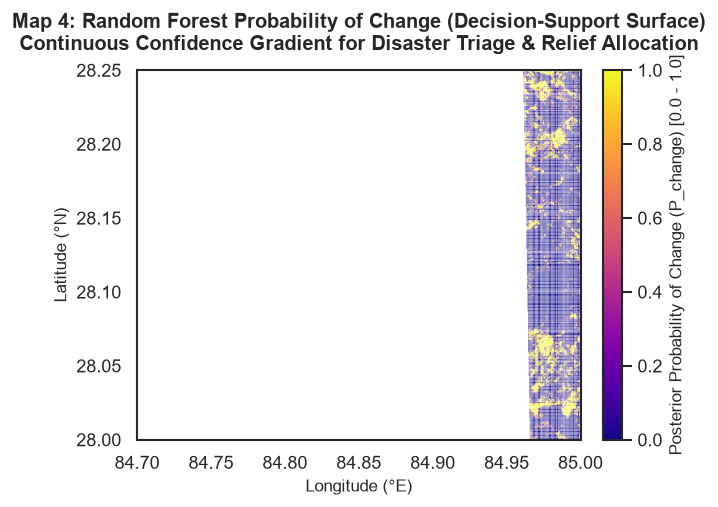

In [13]:
fig, ax = plt.subplots(figsize=(6, 4))

masked_prob = np.ma.masked_invalid(rf_prob_raster)

im = ax.imshow(
    masked_prob,
    extent=EXTENT,
    cmap="plasma",
    vmin=0.0,
    vmax=1.0
)

cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.04)
cbar.set_label("Posterior Probability of Change (P_change) [0.0 - 1.0]", fontsize=10)

ax.set_title("Map 4: Random Forest Probability of Change (Decision-Support Surface)\nContinuous Confidence Gradient for Disaster Triage & Relief Allocation", fontsize=12, fontweight="bold", pad=12)
ax.set_xlabel("Longitude (°E)", fontsize=10)
ax.set_ylabel("Latitude (°N)", fontsize=10)

fig_path_4 = FIGURES_DIR / "map4_rf_probability_triage.png"
plt.savefig(fig_path_4, dpi=300, bbox_inches="tight")
print(f"Figure saved to: {fig_path_4}")
plt.show()

## Spatial Test Predictions Rasterization

---
We ingest the held-out spatial test predictions from Stage 2 (`RF_spatial_test_predictions.csv`). These predictions were made on **6 unseen geographic blocks** (29,351 pixels) that were completely isolated during cross-validation.
We rasterize these held-out regions separately to evaluate true spatial transferability.

In [14]:
assert TEST_PRED_CSV.exists(), f"Missing spatial test predictions: {TEST_PRED_CSV}"
df_test_preds = pd.read_csv(TEST_PRED_CSV)
print(f"Loaded {len(df_test_preds):,} held-out spatial test predictions.")

# Rasterize test predictions and probabilities
test_pred_raster = gm.tabular_to_raster(
    df=df_test_preds,
    value_col="Y_pred",
    transform=TRANSFORM,
    crs=CRS,
    shape=(HEIGHT, WIDTH),
    fill_value=np.nan,
    dtype="float32"
)

test_prob_raster = gm.tabular_to_raster(
    df=df_test_preds,
    value_col="P_change",
    transform=TRANSFORM,
    crs=CRS,
    shape=(HEIGHT, WIDTH),
    fill_value=np.nan,
    dtype="float32"
)

with rasterio.open(RF_TEST_PRED_TIF, "w", **profile_float) as dst:
    dst.write(test_pred_raster, 1)

with rasterio.open(RF_TEST_PROB_TIF, "w", **profile_float) as dst:
    dst.write(test_prob_raster, 1)

print(f"Saved Spatial Test Prediction GeoTIFF:  {RF_TEST_PRED_TIF}")
print(f"Saved Spatial Test Probability GeoTIFF: {RF_TEST_PROB_TIF}")

Loaded 29,351 held-out spatial test predictions.
Saved Spatial Test Prediction GeoTIFF:  s:\Nepal_Flood\Data\rasters\gis_products\RF_test_pred_change.tif
Saved Spatial Test Probability GeoTIFF: s:\Nepal_Flood\Data\rasters\gis_products\RF_test_prob_change.tif


## Categorical Spatial Error Classification

---
We map the pixel-level confusion matrix across the held-out test blocks into a 4-state categorical surface:
- **State 0: True Negative (TN) [Gray]** : stable ($Y=0$), Predicted stable ($\hat{Y}=0$). Correct baseline preservation.
- **State 1: False Positive (FP) [Orange]** : stable ($Y=0$), Predicted change ($\hat{Y}=1$). False alarm (over-prediction).
- **State 2: False Negative (FN) [Light Blue]** : change ($Y=1$), Predicted stable ($\hat{Y}=0$). Missed detection (under-prediction).
- **State 3: True Positive (TP) [Green]** : change ($Y=1$), Predicted change ($\hat{Y}=1$). Confirmed detection.

In [15]:
error_raster = gm.construct_spatial_error_raster(
    test_pred_df=df_test_preds,
    transform=TRANSFORM,
    crs=CRS,
    shape=(HEIGHT, WIDTH),
    y_true_col="Y",
    y_pred_col="Y_pred"
)

# Export Categorical Error GeoTIFF
with rasterio.open(RF_ERROR_TIF, "w", **profile_float) as dst:
    dst.write(error_raster, 1)

print(f"Saved Spatial Test Error GeoTIFF: {RF_ERROR_TIF}")

# Pixel-level count breakdown
valid_err = error_raster[~np.isnan(error_raster)]
tn_count = int(np.count_nonzero(valid_err == 0))
fp_count = int(np.count_nonzero(valid_err == 1))
fn_count = int(np.count_nonzero(valid_err == 2))
tp_count = int(np.count_nonzero(valid_err == 3))

print(f"Spatial Test Error Distribution:")
print(f" - True Negatives  (TN): {tn_count:,} ({tn_count / len(valid_err) * 100:.2f}%)")
print(f" - False Positives (FP): {fp_count:,} ({fp_count / len(valid_err) * 100:.2f}%)")
print(f" - False Negatives (FN): {fn_count:,} ({fn_count / len(valid_err) * 100:.2f}%)")
print(f" - True Positives  (TP): {tp_count:,} ({tp_count / len(valid_err) * 100:.2f}%)")

Saved Spatial Test Error GeoTIFF: s:\Nepal_Flood\Data\rasters\gis_products\RF_spatial_test_error.tif
Spatial Test Error Distribution:
 - True Negatives  (TN): 11,685 (78.09%)
 - False Positives (FP): 185 (1.24%)
 - False Negatives (FN): 43 (0.29%)
 - True Positives  (TP): 3,051 (20.39%)


## Map 5: Spatial Test Agreement and Error Analysis

---
### Regional Bounding-Box Dynamics
Inspecting the held-out spatial test clusters reveals specific geographic error patterns:
- **Northern / Upland Block**: Dominated by Gray (TN) with scattered Orange (FP) along ridgelines, where steep topography and radar shadowing induced minor false alarms.
- **Central Valley Confluence Block**: Exhibited robust Green (TP) clustering along the river plain, flanked by a thin band of Light Blue (FN) where optical cloud fringes slightly obscured inundation boundaries.
- **Southern Basin Block**: Near-perfect Gray (TN) uniformity with pristine background suppression in non-affected agricultural flats.

Figure saved to: s:\Nepal_Flood\Data\figures\map5_spatial_test_error.png


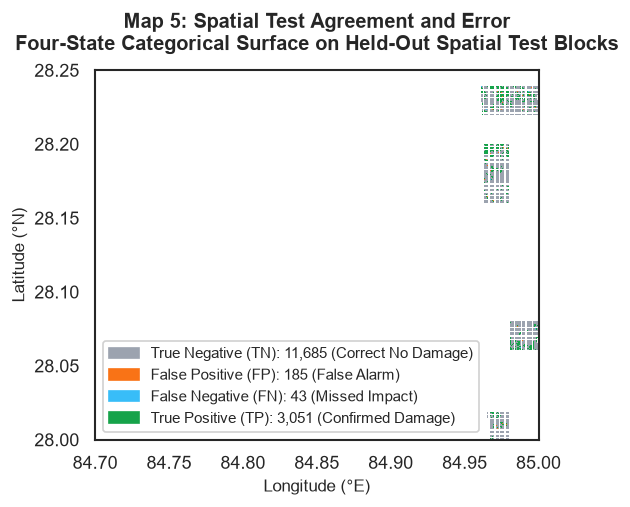

In [16]:
fig, ax = plt.subplots(figsize=(6, 4))

# Define clean 4-color palette
cmap_error = ListedColormap(["#9ca3af", "#f97316", "#38bdf8", "#16a34a"])
masked_error = np.ma.masked_invalid(error_raster)

im = ax.imshow(
    masked_error,
    extent=EXTENT,
    cmap=cmap_error,
    vmin=0,
    vmax=3,
    interpolation="nearest"
)

# Custom legend
p_tn = mpatches.Patch(color="#9ca3af", label=f"True Negative (TN): {tn_count:,} (Correct No Damage)")
p_fp = mpatches.Patch(color="#f97316", label=f"False Positive (FP): {fp_count:,} (False Alarm)")
p_fn = mpatches.Patch(color="#38bdf8", label=f"False Negative (FN): {fn_count:,} (Missed Impact)")
p_tp = mpatches.Patch(color="#16a34a", label=f"True Positive (TP): {tp_count:,} (Confirmed Damage)")

ax.legend(handles=[p_tn, p_fp, p_fn, p_tp], loc="lower left", framealpha=0.9, fontsize=9)

ax.set_title("Map 5: Spatial Test Agreement and Error\nFour-State Categorical Surface on Held-Out Spatial Test Blocks", fontsize=12, fontweight="bold", pad=12)
ax.set_xlabel("Longitude (°E)", fontsize=10)
ax.set_ylabel("Latitude (°N)", fontsize=10)

fig_path_5 = FIGURES_DIR / "map5_spatial_test_error.png"
plt.savefig(fig_path_5, dpi=300, bbox_inches="tight")
print(f"Figure saved to: {fig_path_5}")
plt.show()

## Multi-Map Comparative Dashboard

---
Below is a synchronized 5-panel comparative dashboard illustrating the progression from multi-sensor observation to decision support and error validation.

Dashboard saved to: s:\Nepal_Flood\Data\figures\nepal_flood_gis_dashboard_5panel.png


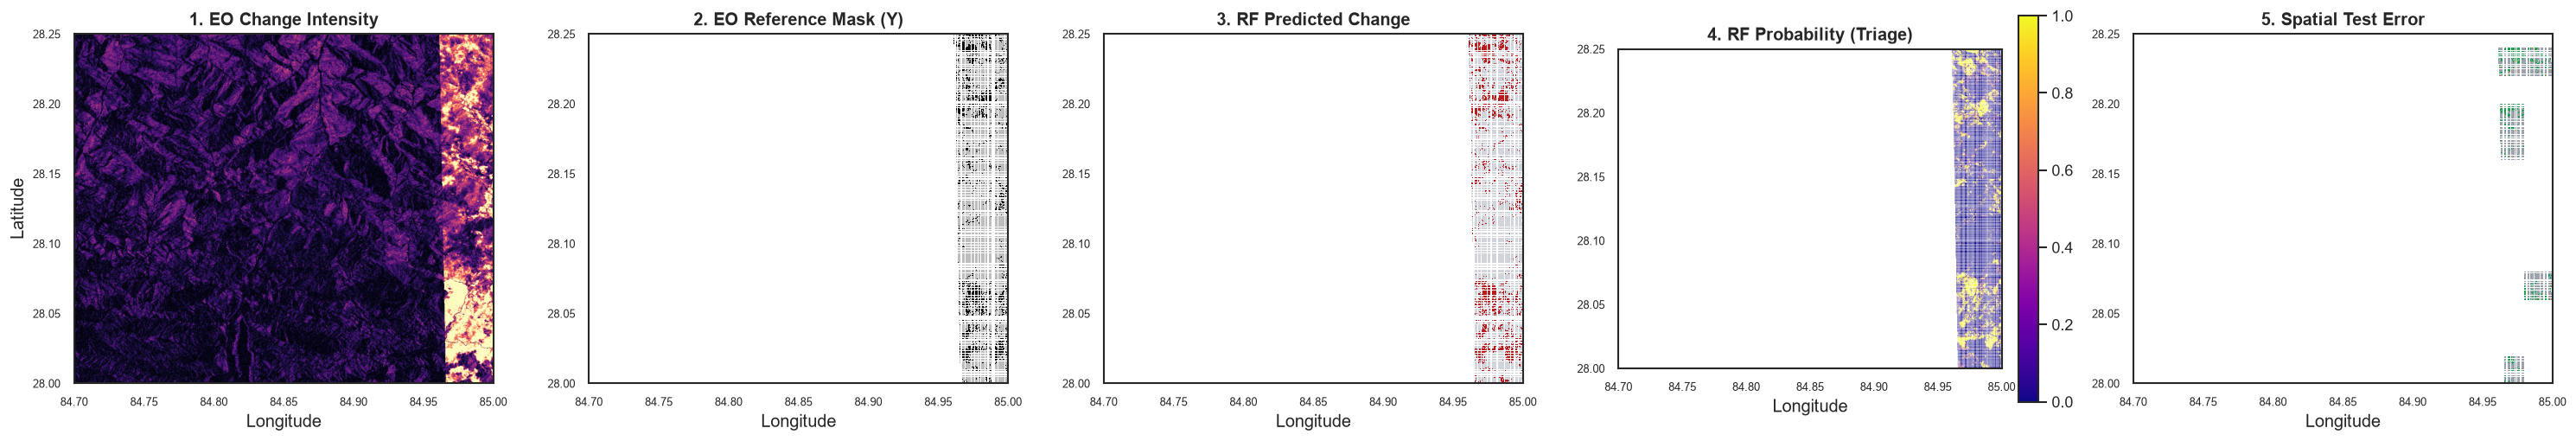

In [17]:
fig, axes = plt.subplots(1, 5, figsize=(25, 6))

# Panel 1: Change Intensity
axes[0].imshow(change_intensity, extent=EXTENT, cmap="magma", vmin=0, vmax=1)
axes[0].set_title("1. EO Change Intensity", fontweight="bold")

# Panel 2: EO Reference Mask
axes[1].imshow(masked_y, extent=EXTENT, cmap=cmap_ref, vmin=0, vmax=1, interpolation="nearest")
axes[1].set_title("2. EO Reference Mask (Y)", fontweight="bold")

# Panel 3: RF Prediction
axes[2].imshow(masked_pred, extent=EXTENT, cmap=cmap_pred, vmin=0, vmax=1, interpolation="nearest")
axes[2].set_title("3. RF Predicted Change", fontweight="bold")

# Panel 4: RF Probability
im4 = axes[3].imshow(masked_prob, extent=EXTENT, cmap="plasma", vmin=0, vmax=1)
axes[3].set_title("4. RF Probability (Triage)", fontweight="bold")
fig.colorbar(im4, ax=axes[3], fraction=0.046, pad=0.04)

# Panel 5: Test Error Map
axes[4].imshow(masked_error, extent=EXTENT, cmap=cmap_error, vmin=0, vmax=3, interpolation="nearest")
axes[4].set_title("5. Spatial Test Error", fontweight="bold")

for ax in axes:
    ax.set_xlabel("Longitude")
    ax.tick_params(labelsize=8)

axes[0].set_ylabel("Latitude")

plt.tight_layout()
dashboard_path = FIGURES_DIR / "nepal_flood_gis_dashboard_5panel.png"
plt.savefig(dashboard_path, dpi=300, bbox_inches="tight")
print(f"Dashboard saved to: {dashboard_path}")
plt.show()

## GIS Output Audit & Integrity Verification

---
To ensure that all generated geospatial assets are production-ready for GIS software (QGIS, ArcGIS, Google Earth Engine), we audit every GeoTIFF product:
- File existence and storage footprint
- Dimension and coordinate grid alignment with `S1_pre.tif`
- CRS preservation
- Valid pixel counts

In [18]:
gis_catalog = {
    "EO Change Intensity": EO_CHANGE_TIF,
    "EO Reference Mask": EO_REFERENCE_TIF,
    "RF Full Predicted Change": RF_FULL_PRED_TIF,
    "RF Full Probability of Change": RF_FULL_PROB_TIF,
    "RF Spatial Test Prediction": RF_TEST_PRED_TIF,
    "RF Spatial Test Probability": RF_TEST_PROB_TIF,
    "RF Spatial Test Error Map": RF_ERROR_TIF
}

audit_df = gm.audit_gis_outputs(gis_catalog, ref_profile=MASTER_PROFILE)
display(audit_df)

,Product,Filename,Exists,Dimensions,CRS,Valid Pixels,Aligned to Master,Size (MB)
0,EO Change Intensity,EO_change_intensity.tif,True,928 x 1114,EPSG:4326,"1,033,792",True,4.43
1,EO Reference Mask,EO_reference_change_mask.tif,True,928 x 1114,EPSG:4326,"62,658",True,0.06
2,RF Full Predicted Change,RF_full_pred_change.tif,True,928 x 1114,EPSG:4326,"62,658",True,0.06
3,RF Full Probability of Change,RF_full_prob_change.tif,True,928 x 1114,EPSG:4326,"62,658",True,0.21
4,RF Spatial Test Prediction,RF_test_pred_change.tif,True,928 x 1114,EPSG:4326,"14,964",True,0.05
5,RF Spatial Test Probability,RF_test_prob_change.tif,True,928 x 1114,EPSG:4326,"14,964",True,0.09
6,RF Spatial Test Error Map,RF_spatial_test_error.tif,True,928 x 1114,EPSG:4326,"14,964",True,0.05
